<a href="https://colab.research.google.com/github/rrankawat/anomaly-detection/blob/main/Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from google.colab import drive

In [ ]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Parameters
data_dir = "/content/drive/My Drive/MVTecAD/bottle"
batch_size = 16
latent_dim = 128
lr = 0.0001
epochs = 10

In [ ]:
# Data transforms
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [ ]:
# Load dataset
def load_mvtec_data(data_dir, batch_size):
    train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=transform)
    val_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

train_loader, val_loader = load_mvtec_data(data_dir, batch_size)

In [ ]:
# ConvVAE model
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(ConvVAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),  # (3, 128, 128) -> (32, 64, 64)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # (32, 64, 64) -> (64, 32, 32)
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # (64, 32, 32) -> (128, 16, 16)
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(128 * 16 * 16, latent_dim)
        self.fc_log_var = nn.Linear(128 * 16 * 16, latent_dim)

        # Decoder
        self.fc_decode = nn.Linear(latent_dim, 128 * 16 * 16)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # (128, 16, 16) -> (64, 32, 32)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # (64, 32, 32) -> (32, 64, 64)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),  # (32, 64, 64) -> (3, 128, 128)
            nn.Sigmoid()  # Normalize output to [0, 1]
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = self.encoder(x).view(x.size(0), -1)
        mu = self.fc_mu(x)
        log_var = self.fc_log_var(x)
        z = self.reparameterize(mu, log_var)
        x = self.fc_decode(z).view(-1, 128, 16, 16)
        return self.decoder(x), mu, log_var

In [ ]:
# VAE loss function
def vae_loss(reconstructed, original, mu, log_var, beta=0.1):
    reconstruction_loss = nn.MSELoss()(reconstructed, original)
    kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return reconstruction_loss + beta * kl_divergence / original.size(0)

In [ ]:
# Initialize model, optimizer
model = ConvVAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

In [ ]:
# Training and validation loops
def train_and_validate(model, train_loader, val_loader, device, epochs):
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0
        for images, _ in train_loader:
            images = images.to(device)
            reconstructed, mu, log_var = model(images)
            loss = vae_loss(reconstructed, images, mu, log_var)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(device)
                reconstructed, mu, log_var = model(images)
                loss = vae_loss(reconstructed, images, mu, log_var)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

train_losses, val_losses = train_and_validate(model, train_loader, val_loader, device, epochs)

Epoch 1/10, Train Loss: 0.1370, Val Loss: 0.1302
Epoch 2/10, Train Loss: 0.1310, Val Loss: 0.1289
Epoch 3/10, Train Loss: 0.1304, Val Loss: 0.1286
Epoch 4/10, Train Loss: 0.1300, Val Loss: 0.1283
Epoch 5/10, Train Loss: 0.1296, Val Loss: 0.1278
Epoch 6/10, Train Loss: 0.1291, Val Loss: 0.1271
Epoch 7/10, Train Loss: 0.1282, Val Loss: 0.1254
Epoch 8/10, Train Loss: 0.1254, Val Loss: 0.1219
Epoch 9/10, Train Loss: 0.1218, Val Loss: 0.1163
Epoch 10/10, Train Loss: 0.1120, Val Loss: 0.1048


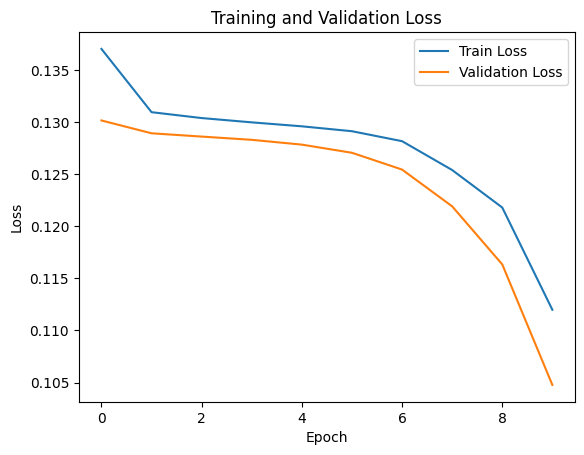

In [ ]:
# Plot training and validation loss
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

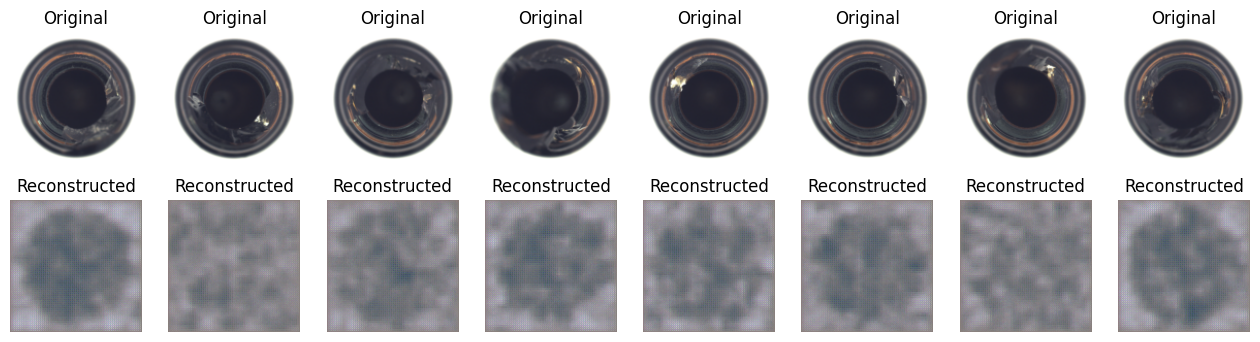

In [ ]:
# Visualize a batch of reconstructed images
def visualize_reconstructions(model, data_loader, device):
    model.eval()
    images, _ = next(iter(data_loader))
    images = images.to(device)
    reconstructed, _, _ = model(images)
    images = images.cpu().numpy()
    reconstructed = reconstructed.cpu().detach().numpy()

    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i in range(8):
        # Original
        axes[0, i].imshow(np.transpose(images[i], (1, 2, 0)))
        axes[0, i].axis("off")
        axes[0, i].set_title("Original")
        # Reconstructed
        axes[1, i].imshow(np.transpose(reconstructed[i], (1, 2, 0)))
        axes[1, i].axis("off")
        axes[1, i].set_title("Reconstructed")
    plt.show()

visualize_reconstructions(model, val_loader, device)